In [3]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

OpenCV: 5.0.0
TensorFlow: 2.22.0-dev20260905
NumPy: 2.4.4


In [4]:
#Contando a quantidade de imagens em cada pasta

from pathlib import Path

def_dir = Path("def_front")
ok_dir = Path("ok_front")

def_images = list(def_dir.glob("*"))
ok_images = list(ok_dir.glob("*"))

print("Imagens defeituosas:", len(def_images))
print("Imagens OK:", len(ok_images))
print("Total:", len(def_images) + len(ok_images))

Imagens defeituosas: 781
Imagens OK: 519
Total: 1300


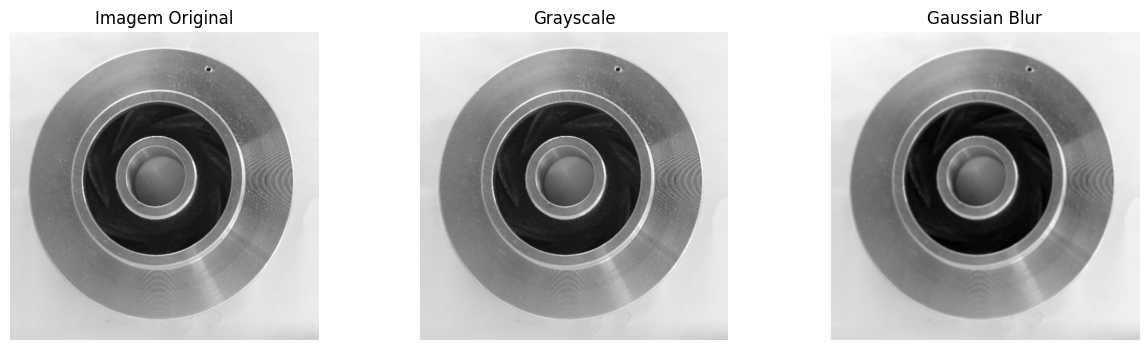

In [5]:

img = cv2.imread("def_front/cast_def_0_91.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

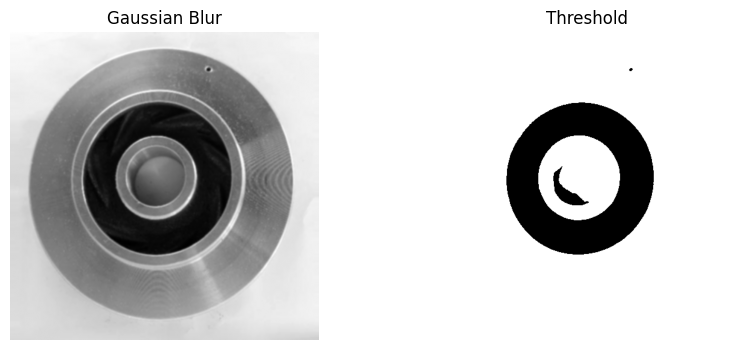

In [6]:
img_thresh = cv2.threshold(img_blur, 80, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_thresh[1], cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.show()

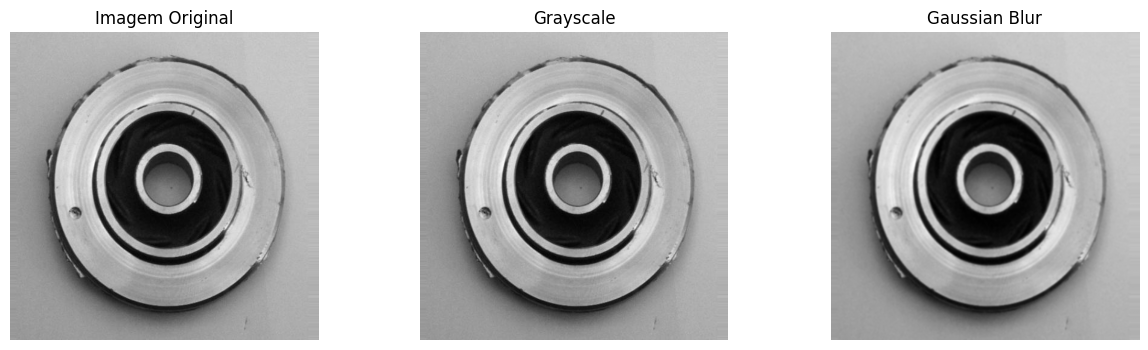

In [7]:
img2 = cv2.imread("def_front/cast_def_0_94.jpeg")

img_rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

img_blur2 = cv2.GaussianBlur(img_gray2, (5, 5), 0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb2)
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gray2, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_blur2, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

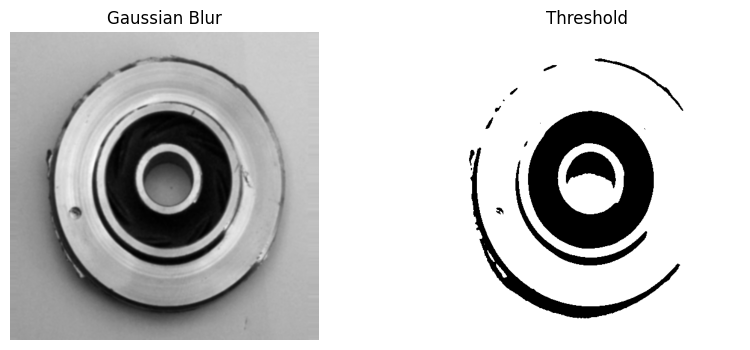

In [8]:
img_thresh2 = cv2.threshold(img_blur2, 80, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_blur2, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_thresh2[1], cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.show()

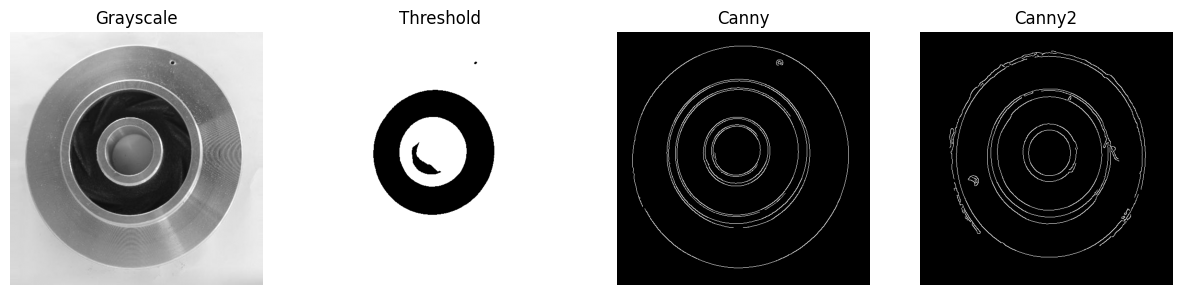

In [9]:
img_canny = cv2.Canny(img_blur, 50, 150)

img_canny2 = cv2.Canny(img_blur2, 50, 150)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_thresh[1], cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_canny2, cmap="gray")
plt.title("Canny2")
plt.axis("off")

plt.show()

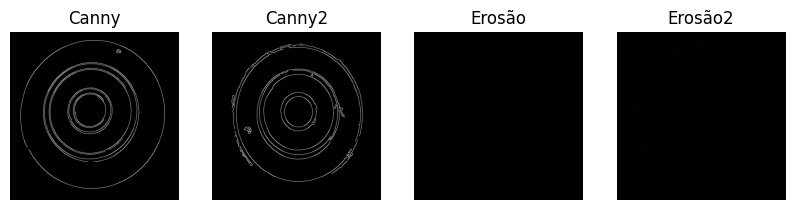

In [10]:
kernel = np.ones((2 , 2), np.uint8)

img_erosao = cv2.erode(
    img_canny,
    kernel,
    iterations=1
)

img_erosao2 = cv2.erode(
    img_canny2,
    kernel,
    iterations=1
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_canny2, cmap="gray")
plt.title("Canny2")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_erosao, cmap="gray")
plt.title("Erosão")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_erosao2, cmap="gray")
plt.title("Erosão2")
plt.axis("off")

plt.show()

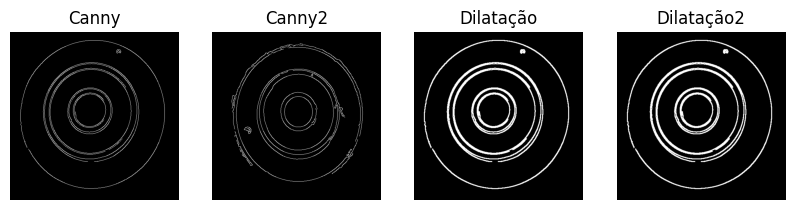

In [11]:
kernel = np.ones((3, 3), np.uint8)

img_dilatada = cv2.dilate(
    img_canny,
    kernel,
    iterations=1
)

img_dilatada2 = cv2.dilate(
    img_canny,
    kernel,
    iterations=1
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_canny2, cmap="gray")
plt.title("Canny2")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_dilatada, cmap="gray")
plt.title("Dilatação")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_dilatada2, cmap="gray")
plt.title("Dilatação2")
plt.axis("off")

plt.show()

In [19]:

dataset_dir = "."

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.


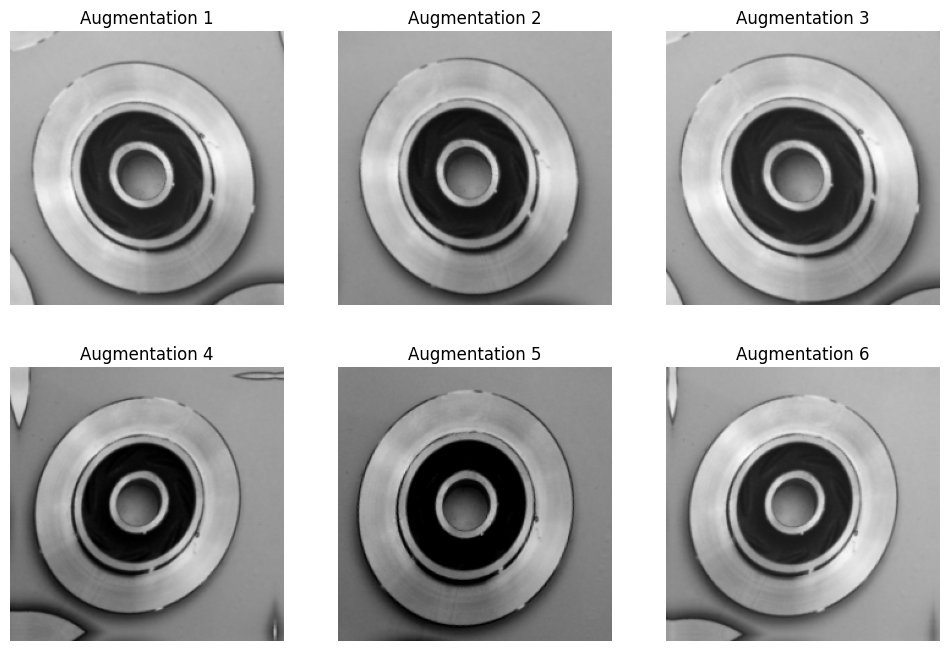

In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1)
])

for imagens, labels in train_ds.take(1):
    imagem_exemplo = imagens[0]
    label_exemplo = labels[0]

    plt.figure(figsize=(12, 8))

for i in range(6):
    imagem_aug = data_augmentation(
        tf.expand_dims(imagem_exemplo, 0),
        training=True
    )[0]

    plt.subplot(2, 3, i + 1)
    plt.imshow(imagem_aug.numpy().astype("uint8"))
    plt.title(f"Augmentation {i + 1}")
    plt.axis("off")

plt.show()

In [21]:
class_names = train_ds.class_names

print(class_names)

['def_front', 'ok_front']


In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

for imagens, labels in train_ds.take(1):
    print("Formato das imagens:", imagens.shape)
    print("Formato dos labels:", labels.shape)
    print("Labels:", labels.numpy())

Formato das imagens: (32, 224, 224, 3)
Formato dos labels: (32,)
Labels: [0 1 0 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 1 0]


In [23]:
conv1 = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu"
)

print(conv1)

<Conv2D name=conv2d, built=False>


In [24]:
pool1 = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2)
)

print(pool1)

<MaxPooling2D name=max_pooling2d, built=True>


In [25]:
conv2 = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu"
)

print(conv2)

<Conv2D name=conv2d_1, built=False>


In [26]:
pool2 = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2)
)

print(pool2)

<MaxPooling2D name=max_pooling2d_1, built=True>


In [27]:
flatten = tf.keras.layers.Flatten()

print(flatten)

<Flatten name=flatten, built=False>


In [29]:
dense1 = tf.keras.layers.Dense(
    64,
    activation="relu"
)

print(dense1)

<Dense name=dense_1, built=False>


In [30]:
output = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)

print(output)

<Dense name=dense_2, built=False>


In [31]:
model = tf.keras.Sequential([
    data_augmentation,
    conv1,
    pool1,
    conv2,
    pool2,
    flatten,
    dense1,
    output
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 186624)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado com sucesso!")

Modelo compilado com sucesso!


In [34]:
#PRIMEIRO TESTE COM 20 EPOCHS

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 531ms/step - accuracy: 0.6010 - loss: 0.9644 - val_accuracy: 0.6385 - val_loss: 0.6312
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 465ms/step - accuracy: 0.6548 - loss: 0.6182 - val_accuracy: 0.6692 - val_loss: 0.6306
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step - accuracy: 0.6808 - loss: 0.6033 - val_accuracy: 0.7269 - val_loss: 0.5679
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 466ms/step - accuracy: 0.6990 - loss: 0.5524 - val_accuracy: 0.7269 - val_loss: 0.5468
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 488ms/step - accuracy: 0.7163 - loss: 0.5514 - val_accuracy: 0.7346 - val_loss: 0.6466
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - accuracy: 0.7096 - loss: 0.5283 - val_accuracy: 0.7769 - val_loss: 0.5188
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step - accuracy: 0.6990 - loss: 0.5642 - val_accuracy: 0.7308 - val_loss: 0.5087
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 486ms/step - accuracy: 0.7260 - loss: 0.5313 - val_accu

In [36]:
print(history.history.keys())

print(len(history.history["loss"]))

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
20
